In [17]:
import os
import numpy as np
from typing import Dict, Tuple, List
import pickle
from utils import utils
from utils.data_utils import load_metadata_and_map

import torch
import cupy as cp
import annoy
import math
from tqdm import tqdm

from matplotlib import pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

In [18]:
METADATA_FILE = "embeddings/id_metadata_arsmagna_test.csv"
TENSOR_DIR = "embeddings/chunked_6s/"

In [19]:
INDEX_FILE = "chunk_6s_index.ann"
KEY_MAP_FILE = "chunk_6s_keymap.pkl"

In [20]:
# 1. Load Tensors
# tensors = utils.load_tensor(TENSOR_DIR, num_workers=16, use_cache=False)


In [21]:
import pandas as pd

metadata_df = pd.read_csv(METADATA_FILE)
print(f"Loaded metadata for {len(metadata_df)} items.")

Loaded metadata for 141138 items.


In [22]:
# load index
idx_size = os.path.getsize(INDEX_FILE)
print(f"Index size: {idx_size} bytes")
print("Loading index...")
index = annoy.AnnoyIndex(1024, "angular")
index.load(INDEX_FILE)

print("Loading key map...")
with open(KEY_MAP_FILE, "rb") as f:
  key_map = pickle.load(f)


Index size: 60038884204 bytes
Loading index...
Loading key map...


In [23]:
# invert key map to track_id and chunk_idx to Annoy integer ID
# Key: TrackID, Value: Dict[ChunkIdx, AnnoyIntegerID]
from collections import defaultdict


inv_key_map: Dict[str, Dict[int, int]] = defaultdict(dict)
for k, v in key_map.items():
  inv_key_map[v[0]][v[1]] = k


$$
\text{score}(Q, D) = \sum_{i = 1}^m \max_{j=1}^n \langle q_i, d_j \rangle
$$

In [24]:
def fetch_embeddings(track_id: str) -> List[torch.Tensor]:
  embeddings = []
  for chunk_index, ann_index in inv_key_map[track_id].items():
    embeddings.append(torch.FloatTensor(index.get_item_vector(ann_index)))
  return embeddings

def load_embeddings_from_pt_file(file_path: str) -> List[torch.Tensor]:
  embeddings = torch.load(file_path)
  # convert to list of tensors
  return list(embeddings)


In [25]:
# ColBERT approximation
target_track_id = '44c6f41c-9408-4e69-b11d-61f438e1b7bf'

# get embeddings from index
target_embeddings: List[torch.Tensor] = fetch_embeddings(target_track_id)
population = len(inv_key_map[target_track_id].items())

In [26]:
target_embeddings_path = "embeddings/chunks_5s_ars/[2016.10.30 [ARS-029] Ariabl'eyeS — 終劇のロマネスク [M3-38]] - 05. Luna, Rena — Romanesque Romancia.allchunks.pt"
target_embeddings = load_embeddings_from_pt_file(target_embeddings_path)
population = len(target_embeddings)

In [27]:
vote_map: Dict[str, int] = defaultdict(int)

# compute kNN, and vote for the most frequent neighbors, based on neighbor key
with tqdm(total=len(target_embeddings), desc="Processing target embeddings") as pbar:
  for embedding in target_embeddings:
    neighbors, distances = index.get_nns_by_vector(embedding.numpy(), 100, search_k=10_000, include_distances=True)
    for neighbor, distance in zip(neighbors, distances):
      # key to get track_id and chunk_idx
      ntrack_id, nchunk_idx = key_map[neighbor]
      # normalize votes by neighbor length, as longer neighbors will probabilistically
      # match more index
      neighbor_length = len(inv_key_map[ntrack_id])
      # vote to elect the most frequent track id based on neighbor
      sim_score = 1.0 - (distance**2) / 2.0
      vote_map[ntrack_id] += sim_score
    pbar.update(1)
# order vote
sorted_vote_map = sorted(vote_map.items(), key=lambda x: x[1], reverse=True)


Processing target embeddings: 100%|██████████| 80/80 [00:44<00:00,  1.78it/s]


In [28]:
# rerank
def calculate_maxsim_score(query_embeddings: torch.Tensor, 
                          doc_embeddings: torch.Tensor) -> float:
  """
  Computes the ColBERT MaxSim score between a Query and a Document.
  
  Args:
      query_embeddings: Tensor of shape (Num_Query_Vectors, Dim)
      doc_embeddings:   Tensor of shape (Num_Doc_Vectors, Dim)
  
  Returns:
      Total relevance score (scalar)
  """
  # 1. Compute Similarity Matrix (Dot Product)
  # Shape: (Num_Query_Vectors, Num_Doc_Vectors)
  # This compares every query vector against every document vector
  sim_matrix = torch.matmul(query_embeddings, doc_embeddings.transpose(0, 1))
  
  # 2. Max-Reduction over Document tokens (dim=1)
  # "For each query vector, what was its best match in the document?"
  # Shape: (Num_Query_Vectors)
  max_scores_per_query_token = torch.max(sim_matrix, dim=1).values
  
  # 3. Summation over Query tokens
  # "Sum up the best matches to get total relevance"
  total_score = torch.sum(max_scores_per_query_token)
  
  return total_score.item()

rank: Dict[str, float] = {}
query_embeddings = torch.stack(target_embeddings)
# normalize query embeddings
query_embeddings = torch.nn.functional.normalize(query_embeddings, p=2, dim=1)

with tqdm(total=len(sorted_vote_map), desc="Computing ColBERT maxsim score") as pbar:
  for track_id, score in sorted_vote_map:
    # get embeddings
    doc_embeddings = torch.stack(fetch_embeddings(track_id))
    # normalize doc embeddings
    doc_embeddings = torch.nn.functional.normalize(doc_embeddings, p=2, dim=1)
    rank[track_id] = calculate_maxsim_score(query_embeddings, doc_embeddings)
    pbar.update(1)


Computing ColBERT maxsim score: 100%|██████████| 2279/2279 [00:10<00:00, 211.08it/s]


In [29]:
# map this to metadata
ranked_metadata = metadata_df[metadata_df['TrackID'].isin(rank.keys())]
ranked_metadata['score'] = ranked_metadata['TrackID'].map(rank)
ranked_metadata = ranked_metadata.sort_values(by='score', ascending=False)
ranked_metadata.head(30)


/tmp/ipykernel_6890/2904246513.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ranked_metadata['score'] = ranked_metadata['TrackID'].map(rank)


,AlbumID,AlbumName,TrackID,TrackName,ArtistName,score
16587,1ecddd00-d213-4639-856b-5ff952521914,真・深淵なるもの,29f81335-b21a-41a9-8d72-35097f11f9d6,Monochrome Solitude,Melonbooks Records,79.257408
115483,d1c4dcd1-1b25-4f1d-a737-295c5ca85d57,運命のヘイト,dcc8a0eb-14c3-42e0-9781-28a2e031c84e,レモネードな君,イノライ,79.237389
38650,46194030-f4bf-40b8-b694-3d3448f23359,Colorful Magic,0109cf59-df64-4408-9d1d-d8c62b0d7504,春の音色にのせて,ふぉれすとぴれお,79.227768
45158,51ab94a3-7634-4471-b1d6-34ab725f44b3,東方御姉様,b44c722f-7ff7-4ee8-b220-8fc2379fc8fe,ultimate_blossom,セブンスヘブンMAXION,79.212532
12616,17a3ebad-2238-43bd-8647-ad3f6a1694c1,アストラルメモリー Episode of UltimateScarlet Re1.5,8c97f9c1-ceb9-4ab5-b94b-f82486d73520,華天月地,ビターショコラ抹茶ラテ,79.209145
60970,6e6fd0ef-a6ec-4b07-a901-a17fa3aa1995,アストラルメモリー Episode of UltimateScarlet Re1.5,4a34ef38-3aed-46c5-a71a-b63b9982c244,華天月地,ビターショコラ抹茶ラテ,79.208733
102799,bb525ce9-f4cc-4b3d-9d40-128558e634be,re☆collection,9c0bc90d-5752-4b41-bdd9-09fb53ae9796,STARRY MAGIC,羽っ鳥もさく共和国,79.207138
130817,ed8ed45d-b414-461f-b3a6-890bff4753c2,東方恋想郷 ～Grazing Heart～,c7df6e24-f529-4831-838d-4cb89212d92b,ultimate_blossom,セブンスヘブンMAXION,79.206390
82025,950bc066-e31d-4415-947c-41beb3938050,東方ジャンプ,08f59fe2-c6b9-4813-ae66-b17eab09899d,UTSUHO,Innocent Key,79.204330
76563,8b47675c-3895-4b83-8464-04d67a4b99b8,花に幽明夜に紫,c7f2f540-195e-4a12-84d0-53814424e20b,夢色シンドローム,Minstrel,79.199104


Visualizing match: Query vs. レモネードな君 (dcc8a0eb-14c3-42e0-9781-28a2e031c84e)


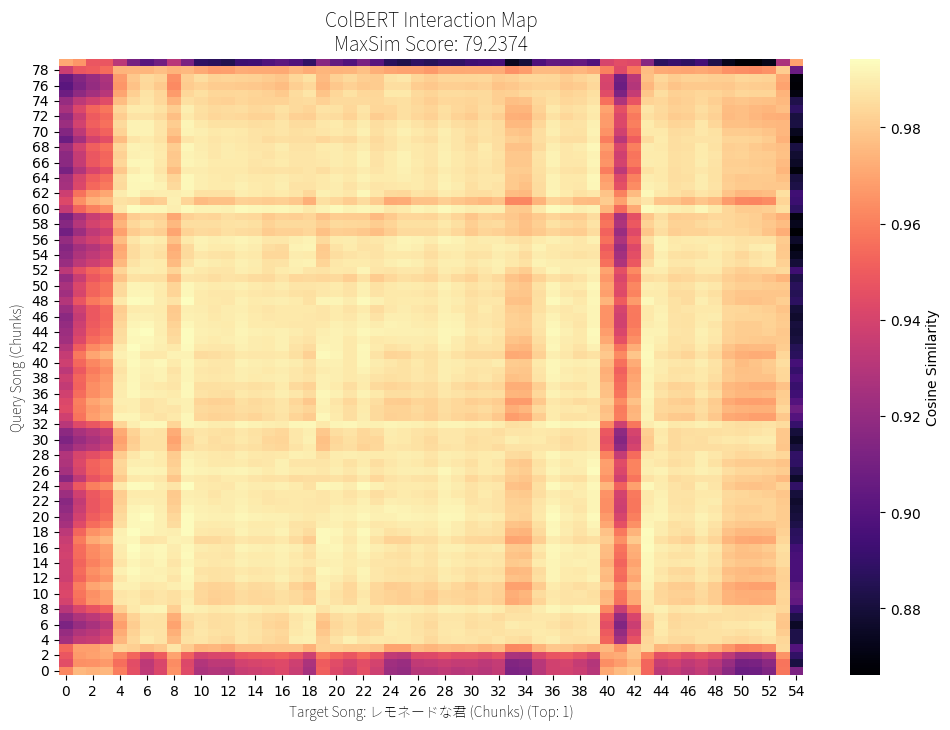

In [30]:
font_path = "fonts/NotoSansJP-VariableFont_wght.ttf"
custom_font = fm.FontProperties(fname=font_path)

TOP_RESULT_IDX = 1

# 1. Get the Top Result Info
top_result_row = ranked_metadata.iloc[TOP_RESULT_IDX]
top_track_id = top_result_row['TrackID']
top_track_title = top_result_row['TrackName']
print(f"Visualizing match: Query vs. {top_track_title} ({top_track_id})")

# 2. Fetch and Normalize Target Embeddings (Re-doing this just for the plot)
top_doc_vecs = fetch_embeddings(top_track_id)
top_doc_embeddings = torch.stack(top_doc_vecs)
top_doc_embeddings = torch.nn.functional.normalize(top_doc_embeddings, p=2, dim=1)

# 3. Compute Similarity Matrix
# shape: [Num_Query_Chunks, Num_Doc_Chunks]
# We move to CPU and numpy for plotting
sim_matrix = torch.matmul(query_embeddings, top_doc_embeddings.transpose(0, 1)).detach().cpu().numpy()

# 4. Plotting
plt.figure(figsize=(12, 8))

# Use a heatmap with a "magma" or "viridis" colormap to show intensity
# Origin='lower' puts (0,0) at the bottom left (standard for time-time plots)
ax = sns.heatmap(sim_matrix, cmap='magma', cbar_kws={'label': 'Cosine Similarity'})

ax.invert_yaxis() # Ensure time starts from bottom-left
plt.xlabel(f"Target Song: {top_track_title} (Chunks) (Top: {TOP_RESULT_IDX})", fontproperties=custom_font,)
plt.ylabel("Query Song (Chunks)", fontproperties=custom_font)
plt.title(f"ColBERT Interaction Map\nMaxSim Score: {top_result_row['score']:.4f}", fontproperties=custom_font, fontsize=14)

plt.show()

# ### Interpret the Heatmap:
# * **Diagonal Lines:** Indicate structural matching (the songs progress similarly).
# * **Horizontal Lines:** A specific motif in the Query matches multiple parts of the Target.
# * **Vertical Lines:** A single moment in the Target matches frequent sounds in the Query.